Now we'll see if you can eliminate some of the controller difficulties using a kalman filter to predict states 

In [79]:
import numpy as np
import scipy.linalg
import scipy.signal
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["figure.dpi"] = 500
class CGM():
    def __init__(self, a, b, c, d, dt, glucose_penalty, insulin_penalty, controller_penalty, derivitive_penalty, target=83, base_insulin=10):
        # This is our target glucose measurement 
        self.target = target
        # This is the baseline amount of insulin
        self.base_insulin = base_insulin 
        # Our model will penalize the difference between the current state and these baselines

        # Define evolution matrices for AX + Bu
        A = np.array([[-a, -b], [d, -c]])
        B = np.array([[0], [1]])

        # Now we convert to a discrete system since we only sample every few minutes
        # see https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.cont2discrete.html#scipy.signal.cont2discrete
        discrete_system = scipy.signal.cont2discrete((A, B, np.eye(2), np.zeros((2,1))), dt, method='zoh')
        self.A = discrete_system[0]
        self.B = discrete_system[1]
        self.Q = np.array([[glucose_penalty, 0], [0, insulin_penalty]])
        
        # Augment A and B for the 3-state regime (current glucose, insulin, past glucose)
        self.A2 = np.pad(self.A, ((0,1), (0,1)), mode='constant')
        self.A2[2, 0] = 1.0 
        self.B2 = np.pad(self.B, ((0,1), (0,0)), mode='constant')
        
        # Q2 requires cross-terms to properly penalize the difference (current - past)^2
        self.Q2 = np.array([
            [glucose_penalty + derivitive_penalty, 0, -derivitive_penalty],
            [0, insulin_penalty, 0],
            [-derivitive_penalty, 0, derivitive_penalty]
        ])
        
        self.R = np.array([controller_penalty])
        

        self.B3 = np.array([[1], [0]]) 
        
        self.K1, self.K2, self.K3 = self.fit()
        self.past = None

    def fit(self):
        # Solves discrete algebraic riccati equations
        P = scipy.linalg.solve_discrete_are(self.A, self.B, self.Q, self.R)
        K1 = np.linalg.inv(self.R + self.B.T @ P @ self.B) @ (self.B.T @ P @ self.A)
        
        # Pass the augmented matrices to the middle regime solver
        P2 = scipy.linalg.solve_discrete_are(self.A2, self.B2, self.Q2, self.R)
        K2 = np.linalg.inv(self.R + self.B2.T @ P2 @ self.B2) @ (self.B2.T @ P2 @ self.A2)
        
        P3 = scipy.linalg.solve_discrete_are(self.A, self.B3, self.Q, self.R)
        # Fixed typo: K3 must use P3, not P
        K3 = np.linalg.inv(self.R + self.B3.T @ P3 @ self.B3) @ (self.B3.T @ P3 @ self.A)
        
        return K1, K2, K3

    def control(self, current_values):
        """Given the value observed by the CGM use the objective to apply optimal control"""
        # First we calculate the errors
        glucose, insulin = current_values
        x1 = glucose - self.target
        x2 = insulin - self.base_insulin
        
        if self.past == None:
            self.past = x1 
            
        xk = np.array([[x1], [x2]])
        
        if glucose > 160:
            u = -self.K1 @ xk
        elif glucose < 60:
            u = -self.K3 @ xk
        else:
            xk = np.array([[x1], [x2], [self.past]])
            u = -self.K2 @ xk
            
        # We can't deliver negative insulin, the indexing is because u is technically a matrix
        u = max(0.0, u[0][0] + self.base_insulin)
        
        # Track the error state, not the raw glucose value
        self.past = x1 
        return u

In [33]:
def square_wave(start, length, magnitude):
    vals = np.zeros(1440)
    size = magnitude / length
    for i in range(length):
        vals[start+i] = size + 0.1 * np.random.uniform(-np.abs(size), np.abs(size))
    return vals

In [34]:
import random
def spike():
    # First we create an empty array of the correct length 
    ep = 1e-6
    spikes = np.zeros(1440)

    # We model the dawn phenomenon with an average spike of 20 mg/dl
    dp = random.randint(180, 480)

    # Random scaling 
    dpscale = random.uniform(ep, 2)
    spikes[dp] = dpscale * 20

    # We model breakfast with a single spike of average 40
    bs = random.randint(420, 540)
    bscale = random.uniform(ep, 2)
    bs_magnitude = bscale * 40
    bs_length = random.randint(6, 12)
    spikes += square_wave(bs, bs_length, bs_magnitude)

    # We next model lunch with a single spike of average 60
    ls = random.randint(660, 780)
    lscale = random.uniform(ep, 2)
    l_magnitude = lscale * 60
    l_length = random.randint(6, 24)
    spikes += square_wave(ls, l_length, l_magnitude)

    # We model dinner with two spikes 60 and 20 seperated by 20 minutes
    ds = random.randint(1080, 1200)
    dscale = random.uniform(ep, 2)
    d_magnitude = dscale * 80
    d_length = random.randint(6, 36)
    spikes += square_wave(ds, d_length, d_magnitude)

    # We add a snack
    ss = random.randint(360, 1380)
    sscale = random.uniform(ep, 2)
    ss_magnitude = sscale * 20
    ss_length = random.randint(6, 9)
    spikes += square_wave(ss, ss_length, ss_magnitude)

    # Now we add exercise
    es = random.randint(360, 1380)
    escale = random.uniform(ep, 2)
    es_magnitude = -escale* 35
    es_length = random.randint(1, 12)
    spikes += square_wave(es, es_length, es_magnitude)


    var = np.random.uniform(.6, 1.4)
    spikes *= var
    
    return spikes

In [35]:
spikes = spike()

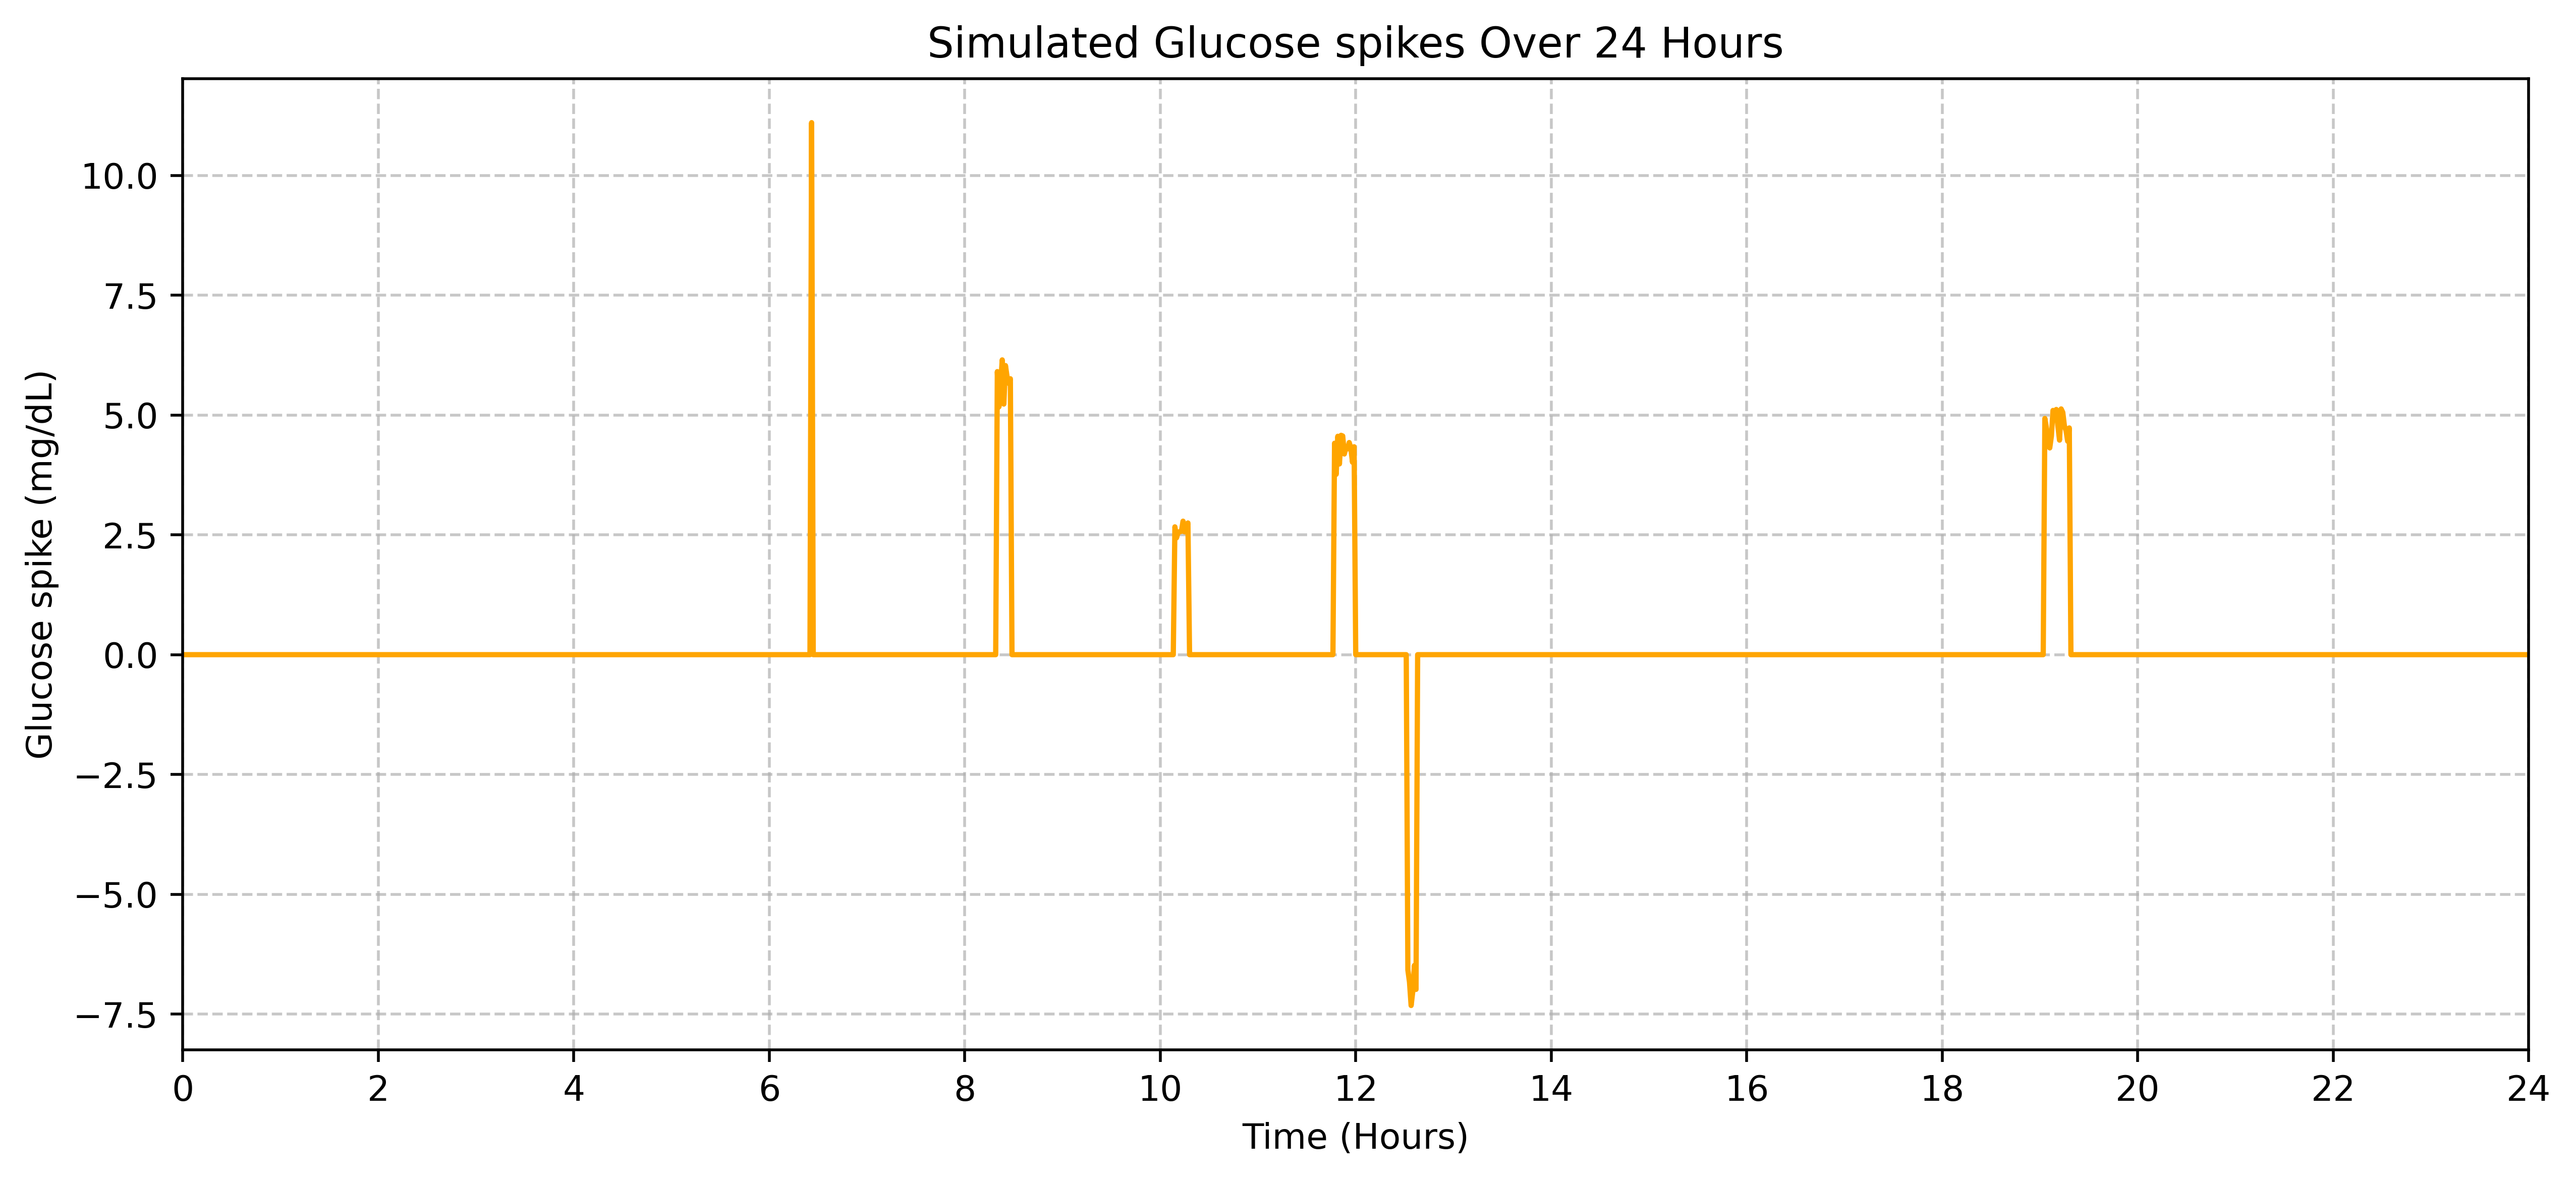

In [73]:
import matplotlib.pyplot as plt
import numpy as np

# Generate the spikes array using your existing function
spikes = spike()

# Convert the 1440 minute indices into hours for the x-axis
hours = np.arange(1440) / 60.0

plt.figure(figsize=(12, 5))
plt.plot(hours, spikes, label='Meal & Exercise Spikes', color='orange')

# Formatting the plot
plt.title('Simulated Glucose spikes Over 24 Hours')
plt.xlabel('Time (Hours)')
plt.ylabel('Glucose spike (mg/dL)')
plt.xlim(0, 24)
plt.xticks(np.arange(0, 25, 2)) # Set tick marks every 2 hours
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

Here's where we start making changes

We resuse the Kalman filter class from the LQG lab

In [45]:
class KalmanFilter:
    """
    Implementation of the Kalman Filter

    Given observations and a model, estimates true states by blending the model
    and observations according to approximated error
    """

    def __init__(self, A, B, H, W, D, N):
        self.A = A
        self.B = B
        self.H = H
        self.W = W
        self.D = D
        self.N = N
        self.dimx = A.shape[0]
        self.dimz = H.shape[0]

    def fit(self):
        """
        Computes and saves the gain matrices Lks
        """
        S = self.W
        L = np.zeros((self.N, self.dimx, self.dimz))
        I = np.eye(self.dimx)
        for i in range(self.N):
            L[i] = S @ self.H.T @ np.linalg.inv(self.H @ S @ self.H.T + self.D)
            Supdate = (I - L[i] @ self.H) @ S
            newS = self.A @ Supdate @ self.A.T + self.W
            S = newS
        self.L = L


    def predict_state(self, xk, uk):
        """
        Returns the next predicted state

        Parameters:
            x_k (ndarray) - The last estimated state
            u_k (ndarray) - The control at the given index

        Returns:
            x_k1|k (ndarray) - The next predicted state
        """
        return self.A @ xk + self.B@uk

    def update_state(self, k, xk, zk):
        """
        Returns the next estimated state

        Parameters:
            k (int) - The index of the state
            x_k1|k (ndarray) - The next predicted state
            z_k1 (ndarray) - The observations at the given index

        Returns:
            x_k1 (ndarray) - The next estimated state
        """
        return xk + self.L[k] @ (zk - self.H @ xk)

We modify the simulation function

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
def simulate_kalman(spikes, t_steps, dt, starting, a, b, c, d, glucose_penalty, insulin_penalty, controller_penalty, derivitive_penalty, target=83, base_insulin=10, step_delay=6):
    cgm = CGM(a, b, c, d, dt, glucose_penalty, insulin_penalty, controller_penalty, derivitive_penalty, target=83, base_insulin=10)
    # Create Matrices for the filter
    H = np.array([[1.0, 0.0]])
    W = np.array([[100.0, 0.0], [0.0, 1.0]])
    D = np.array([[5.0]])
    N_steps = int(t_steps/dt)
    kf = KalmanFilter(cgm.A, cgm.B, H, W, D, N_steps)
    kf.fit()
    initial_error = starting - np.array([target, base_insulin])
    kf_state = initial_error.reshape(2, 1)
    U_hist = [base_insulin] * (step_delay + 1)
    def fun(t, x, u):
        xerr = x - np.array([target, base_insulin])
        uerr = u - base_insulin
        dxdt = np.array([[-a, -b], [d, -c]]) @ xerr + np.array([0, 1]) * uerr
        #Make sure we don't get negative insulin
        if x[1] <= 0 and dxdt[1] < 0:
            dxdt[1] = 0
        return dxdt
    current = starting
    t_hist = []
    y_hist = []
    est_hist = []
    readings = [starting.copy()]
    for t in range(0, t_steps, dt):
        # Calculate which L[k] we need
        k = int(t/dt)
        current[0] += np.sum(spikes[t:t+dt])
        # Time delay of cgm
        if step_delay == 0:
            delayed = current.copy()
        elif len(readings) > step_delay:
            delayed = readings[-step_delay] 
        else:
            delayed = readings[0]
        # Here we want to predict what the actual state is instead of the delayed
        zk = np.array([[delayed[0] - target]])
        kf_state = kf.update_state(k, kf_state, zk)
        # We simulate the effects of the past injections and update the model, for each of the "blind" steps
        sim = kf_state.copy()
        if step_delay > 0:
            for past in U_hist[-step_delay:]:
                past_err = np.array([[past - base_insulin]])
                sim = kf.predict_state(sim, past_err)
        # Translate from errors to actual states
        est = sim.flatten() + np.array([target, base_insulin])
        est_hist.append(est)
        u = cgm.control(est)
        U_hist.append(u)
        # Now we move the filter forwards in time
        old_err = np.array([[U_hist[-(step_delay + 1)] - base_insulin]])
        kf_state = kf.predict_state(kf_state, old_err)
        sol = solve_ivp(fun=fun, t_span=(t, t+dt), y0=current, args=(u,))
        current = np.maximum(0, sol.y[:, -1])
        readings.append(current.copy())
        t_hist.append(sol.t)
        y_hist.append(sol.y)
    return np.concatenate(t_hist), np.concatenate(y_hist, axis=1), np.array(est_hist).T



t_steps = 1440
dt = 5
starting = np.array([85, 15])
a = 0.1
b = 0.01
c = 0.05
d = 0.0
glucose_penalty = 10
insulin_penalty = 5
controller_penalty = 100
derivitive_penalty = 2
step_delay = 0
t, states, estimate = simulate_kalman(spikes, t_steps, dt, starting, a, b, c, d, glucose_penalty, insulin_penalty, controller_penalty, derivitive_penalty, target=83, base_insulin=10, step_delay=step_delay)


In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
def simulate(spikes, t_steps, dt, starting, a, b, c, d, glucose_penalty, insulin_penalty, controller_penalty, derivitive_penalty, target=83, base_insulin=10, step_delay=6):
    cgm = CGM(a, b, c, d, dt, glucose_penalty, insulin_penalty, controller_penalty, derivitive_penalty, target=83, base_insulin=10)
    def fun(t, x, u):
        xerr = x - np.array([target, base_insulin])
        uerr = u - base_insulin
        dxdt = np.array([[-a, -b], [d, -c]]) @ xerr + np.array([0, 1]) * uerr
        #Make sure we don't get negative insulin
        if x[1] <= 0 and dxdt[1] < 0:
            dxdt[1] = 0
        return dxdt
    current = starting
    t_hist = []
    y_hist = []
    readings = [starting.copy()]
    for t in range(0, t_steps, dt):
        current[0] += np.sum(spikes[t:t+dt])
        # Time delay of cgm
        if step_delay == 0:
            delayed = current.copy()
        elif len(readings) > step_delay:
            delayed = readings[-step_delay] 
        else:
            delayed = readings[0] 
        u = cgm.control(delayed)
        sol = solve_ivp(fun=fun, t_span=(t, t+dt), y0=current, args=(u,))
        current = np.maximum(0, sol.y[:, -1])
        readings.append(current.copy())
        t_hist.append(sol.t)
        y_hist.append(sol.y)
    return np.concatenate(t_hist), np.concatenate(y_hist, axis=1)



Let's see if it can deal with our delayed function without heavily penalizing the controller

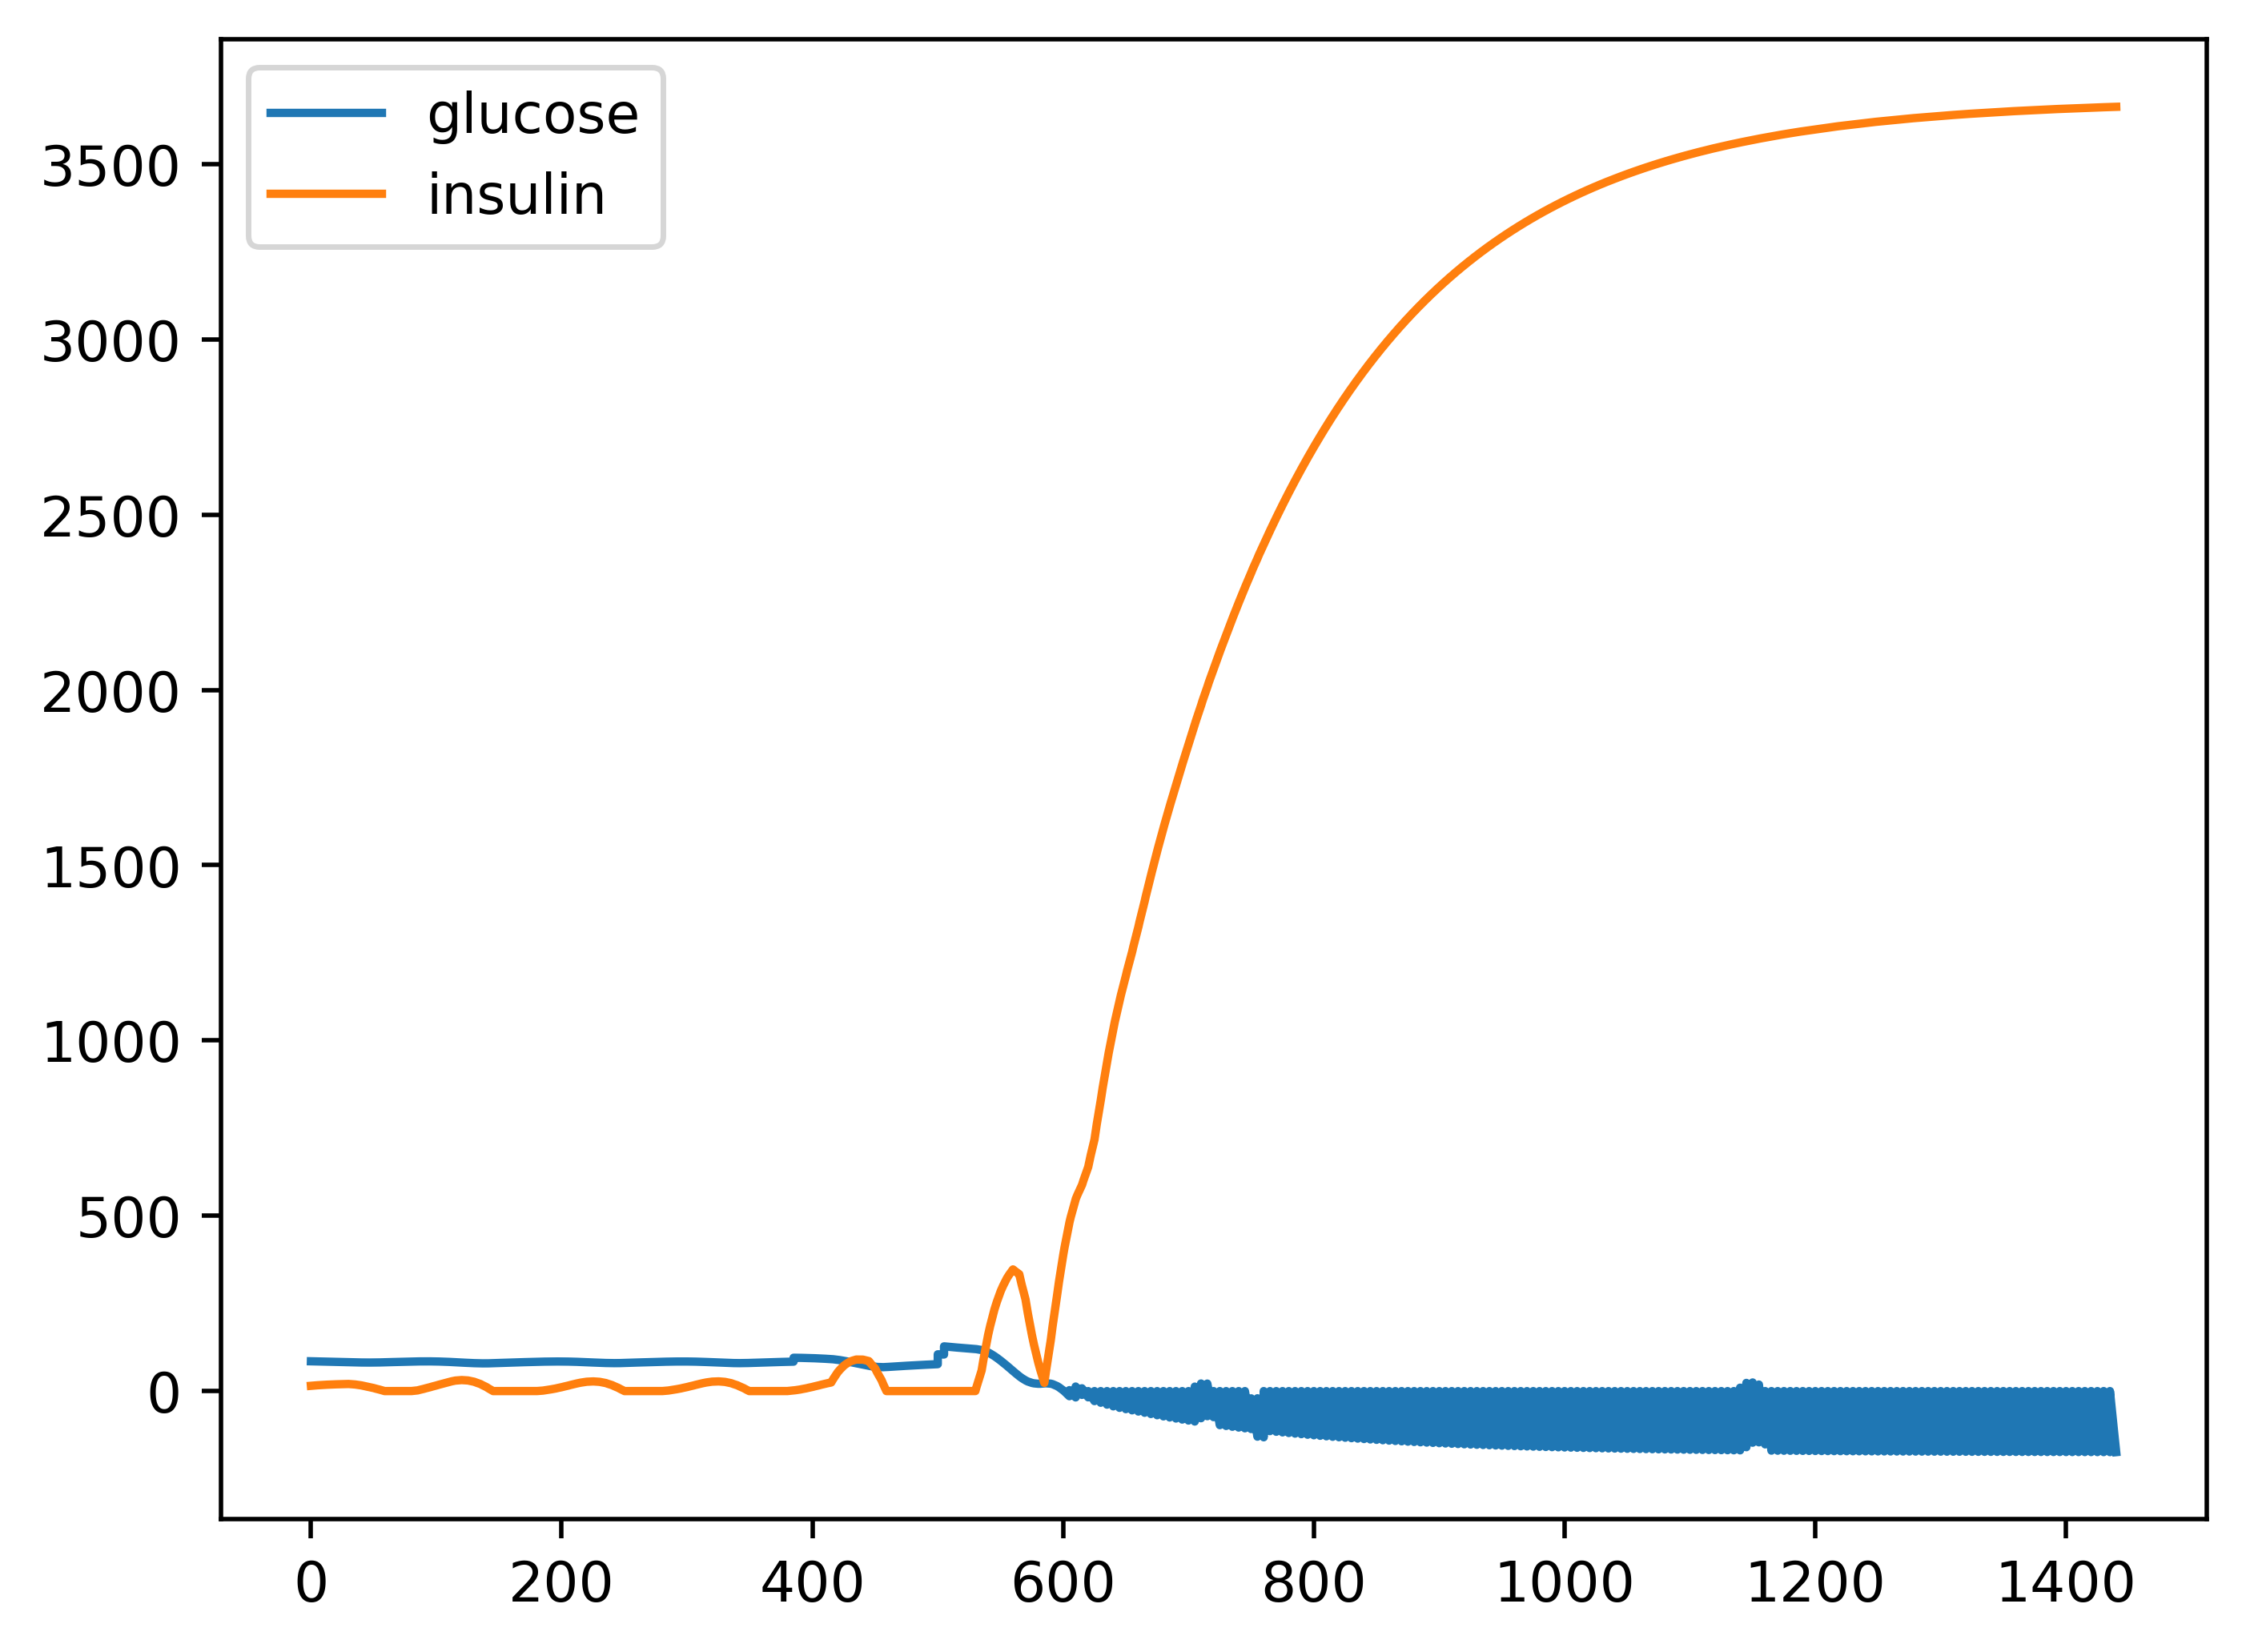

In [88]:
t_steps = 1440
dt = 5
starting = np.array([85, 15])
a = 0.01
b = 0.01
c = 0.05
d = 0.0
glucose_penalty = 100
insulin_penalty = 2
controller_penalty = 100
derivitive_penalty = 2
step_delay = 6
t, states = simulate(spikes, t_steps, dt, starting, a, b, c, d, glucose_penalty, insulin_penalty, controller_penalty, derivitive_penalty, target=83, base_insulin=10, step_delay=step_delay)

plt.plot(t, states[0], label='glucose')
plt.plot(t, states[1], label='insulin')
plt.legend()
plt.show()

same settings but with the Kalman filter

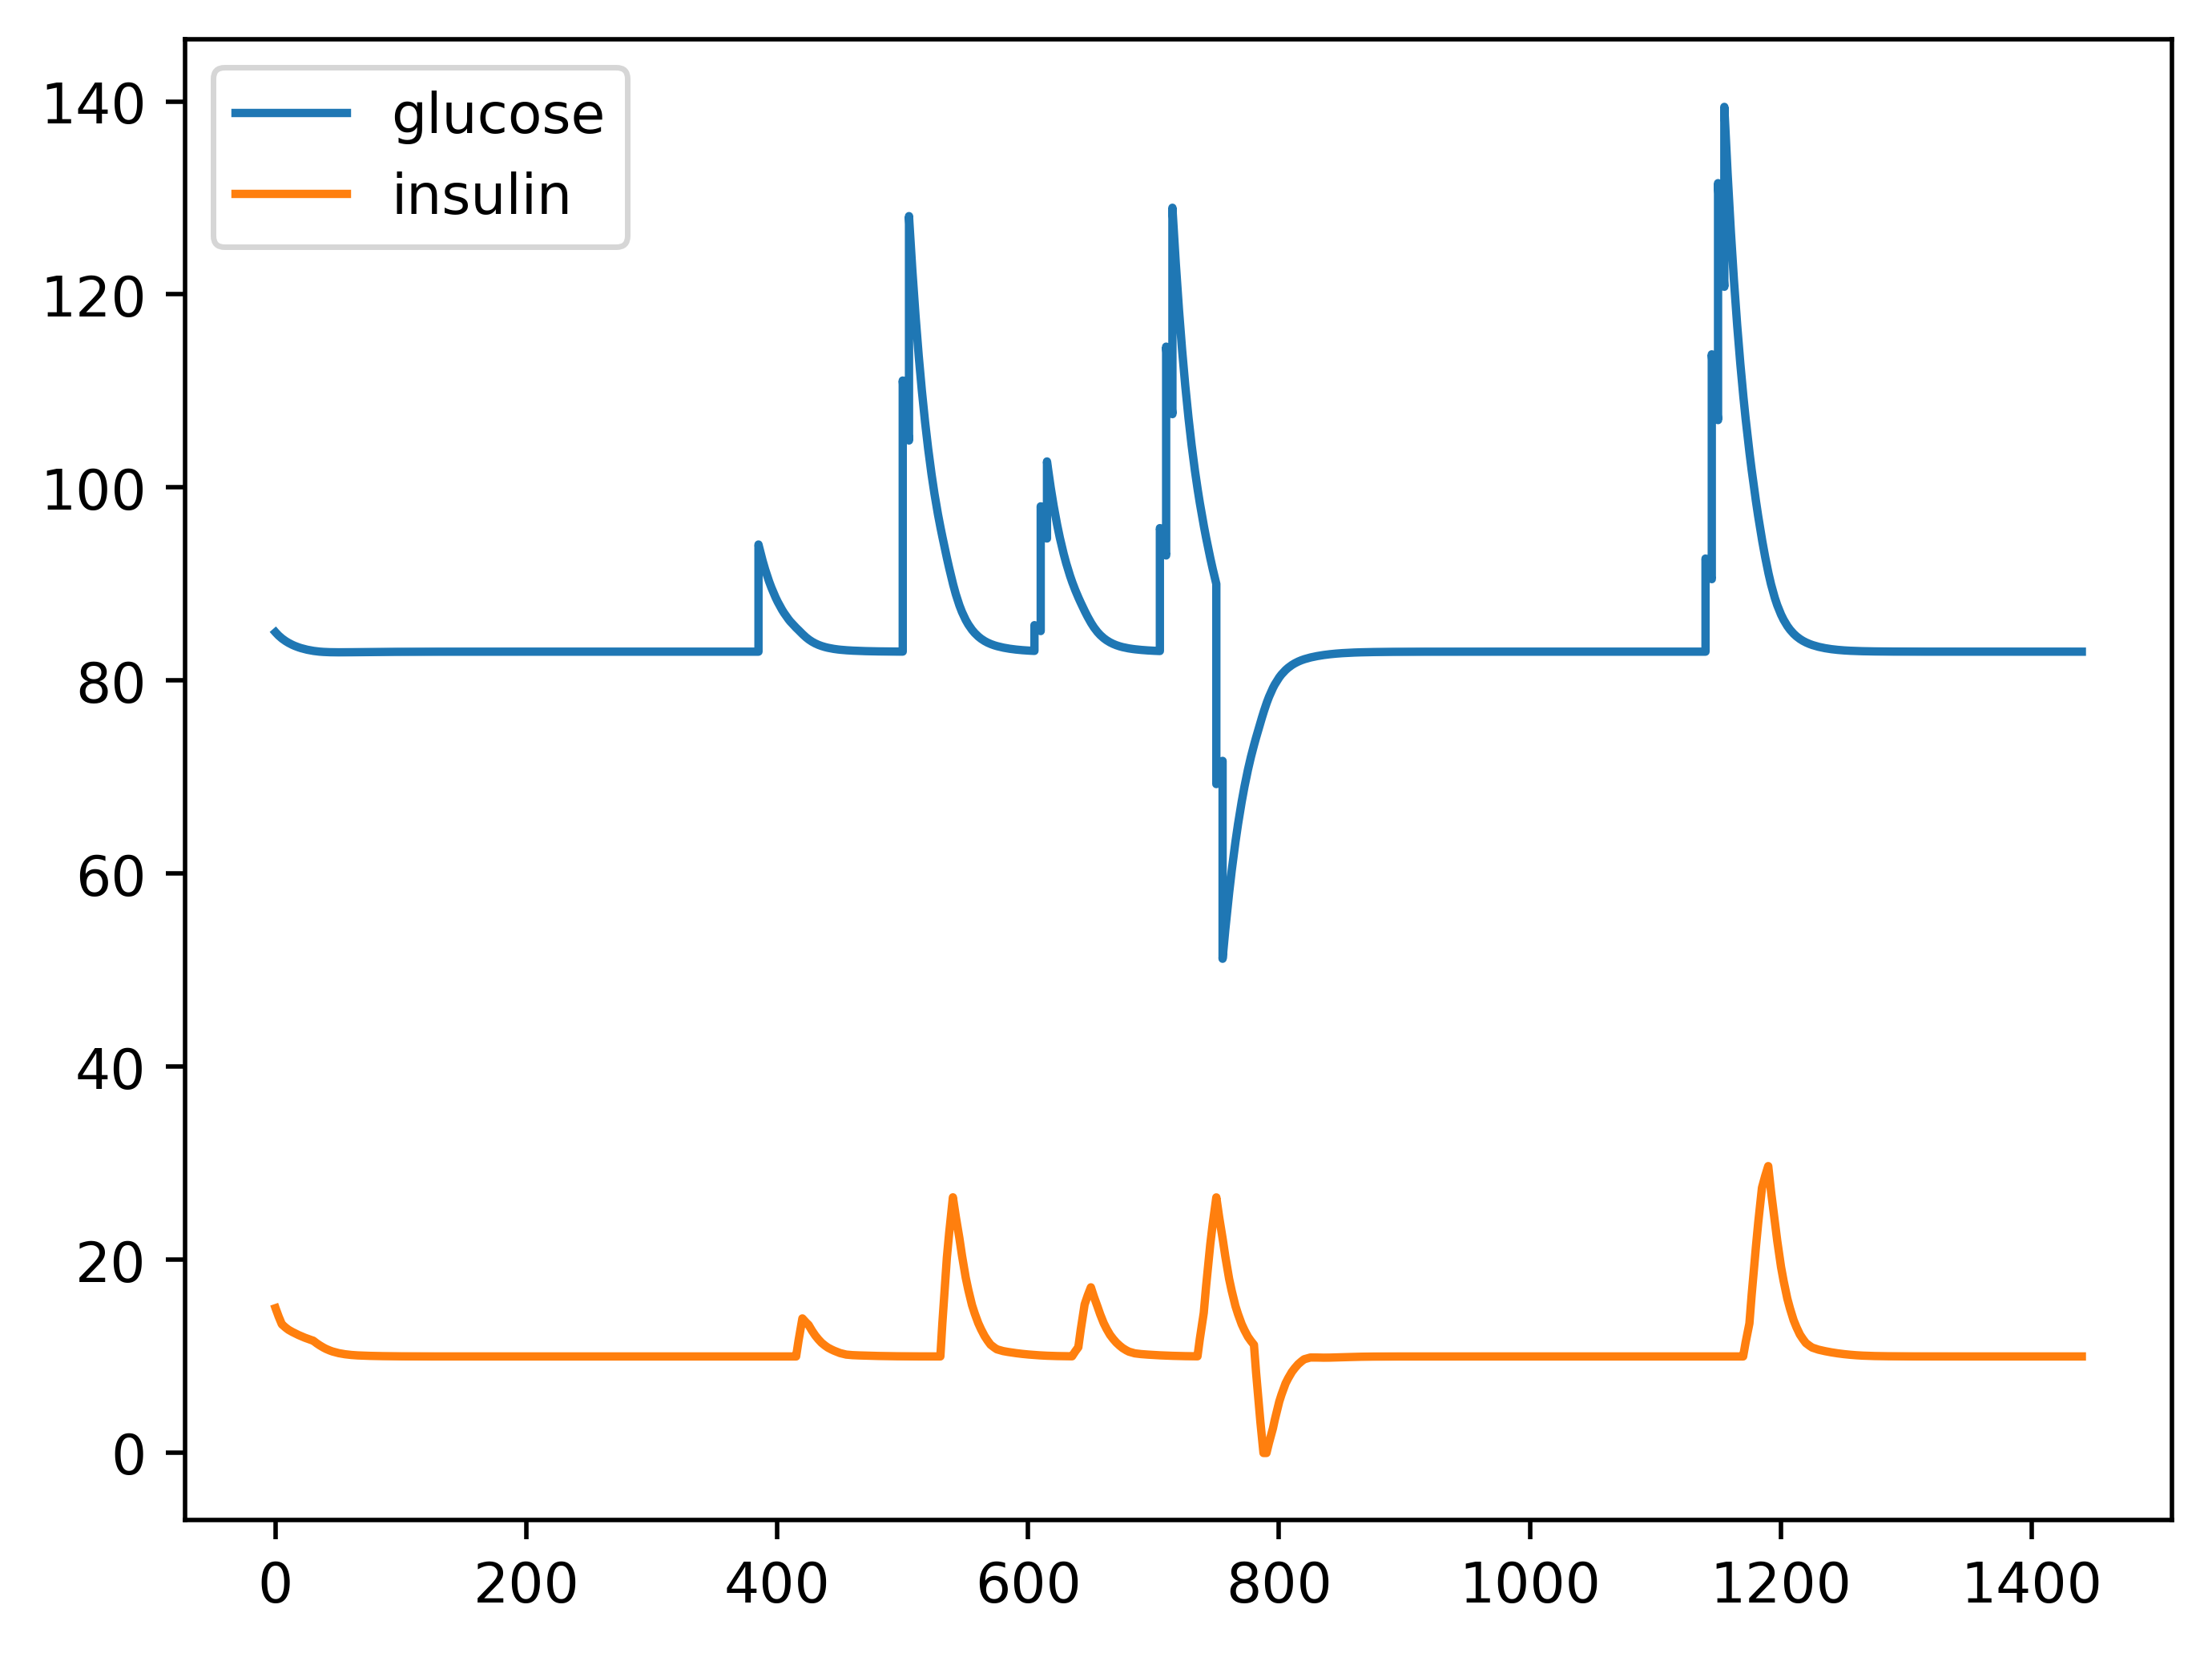

In [ ]:
t_steps = 1440
dt = 5
starting = np.array([85, 15])
a = 0.05
b = 0.01
c = 0.05
d = 0.0
glucose_penalty = 10
insulin_penalty = 2
controller_penalty = 10
derivitive_penalty = 2
step_delay = 6


plt.plot(t, states[0], label='glucose')
plt.plot(t, states[1], label='insulin')
plt.legend()
plt.show()

In [97]:
spikes = spike()

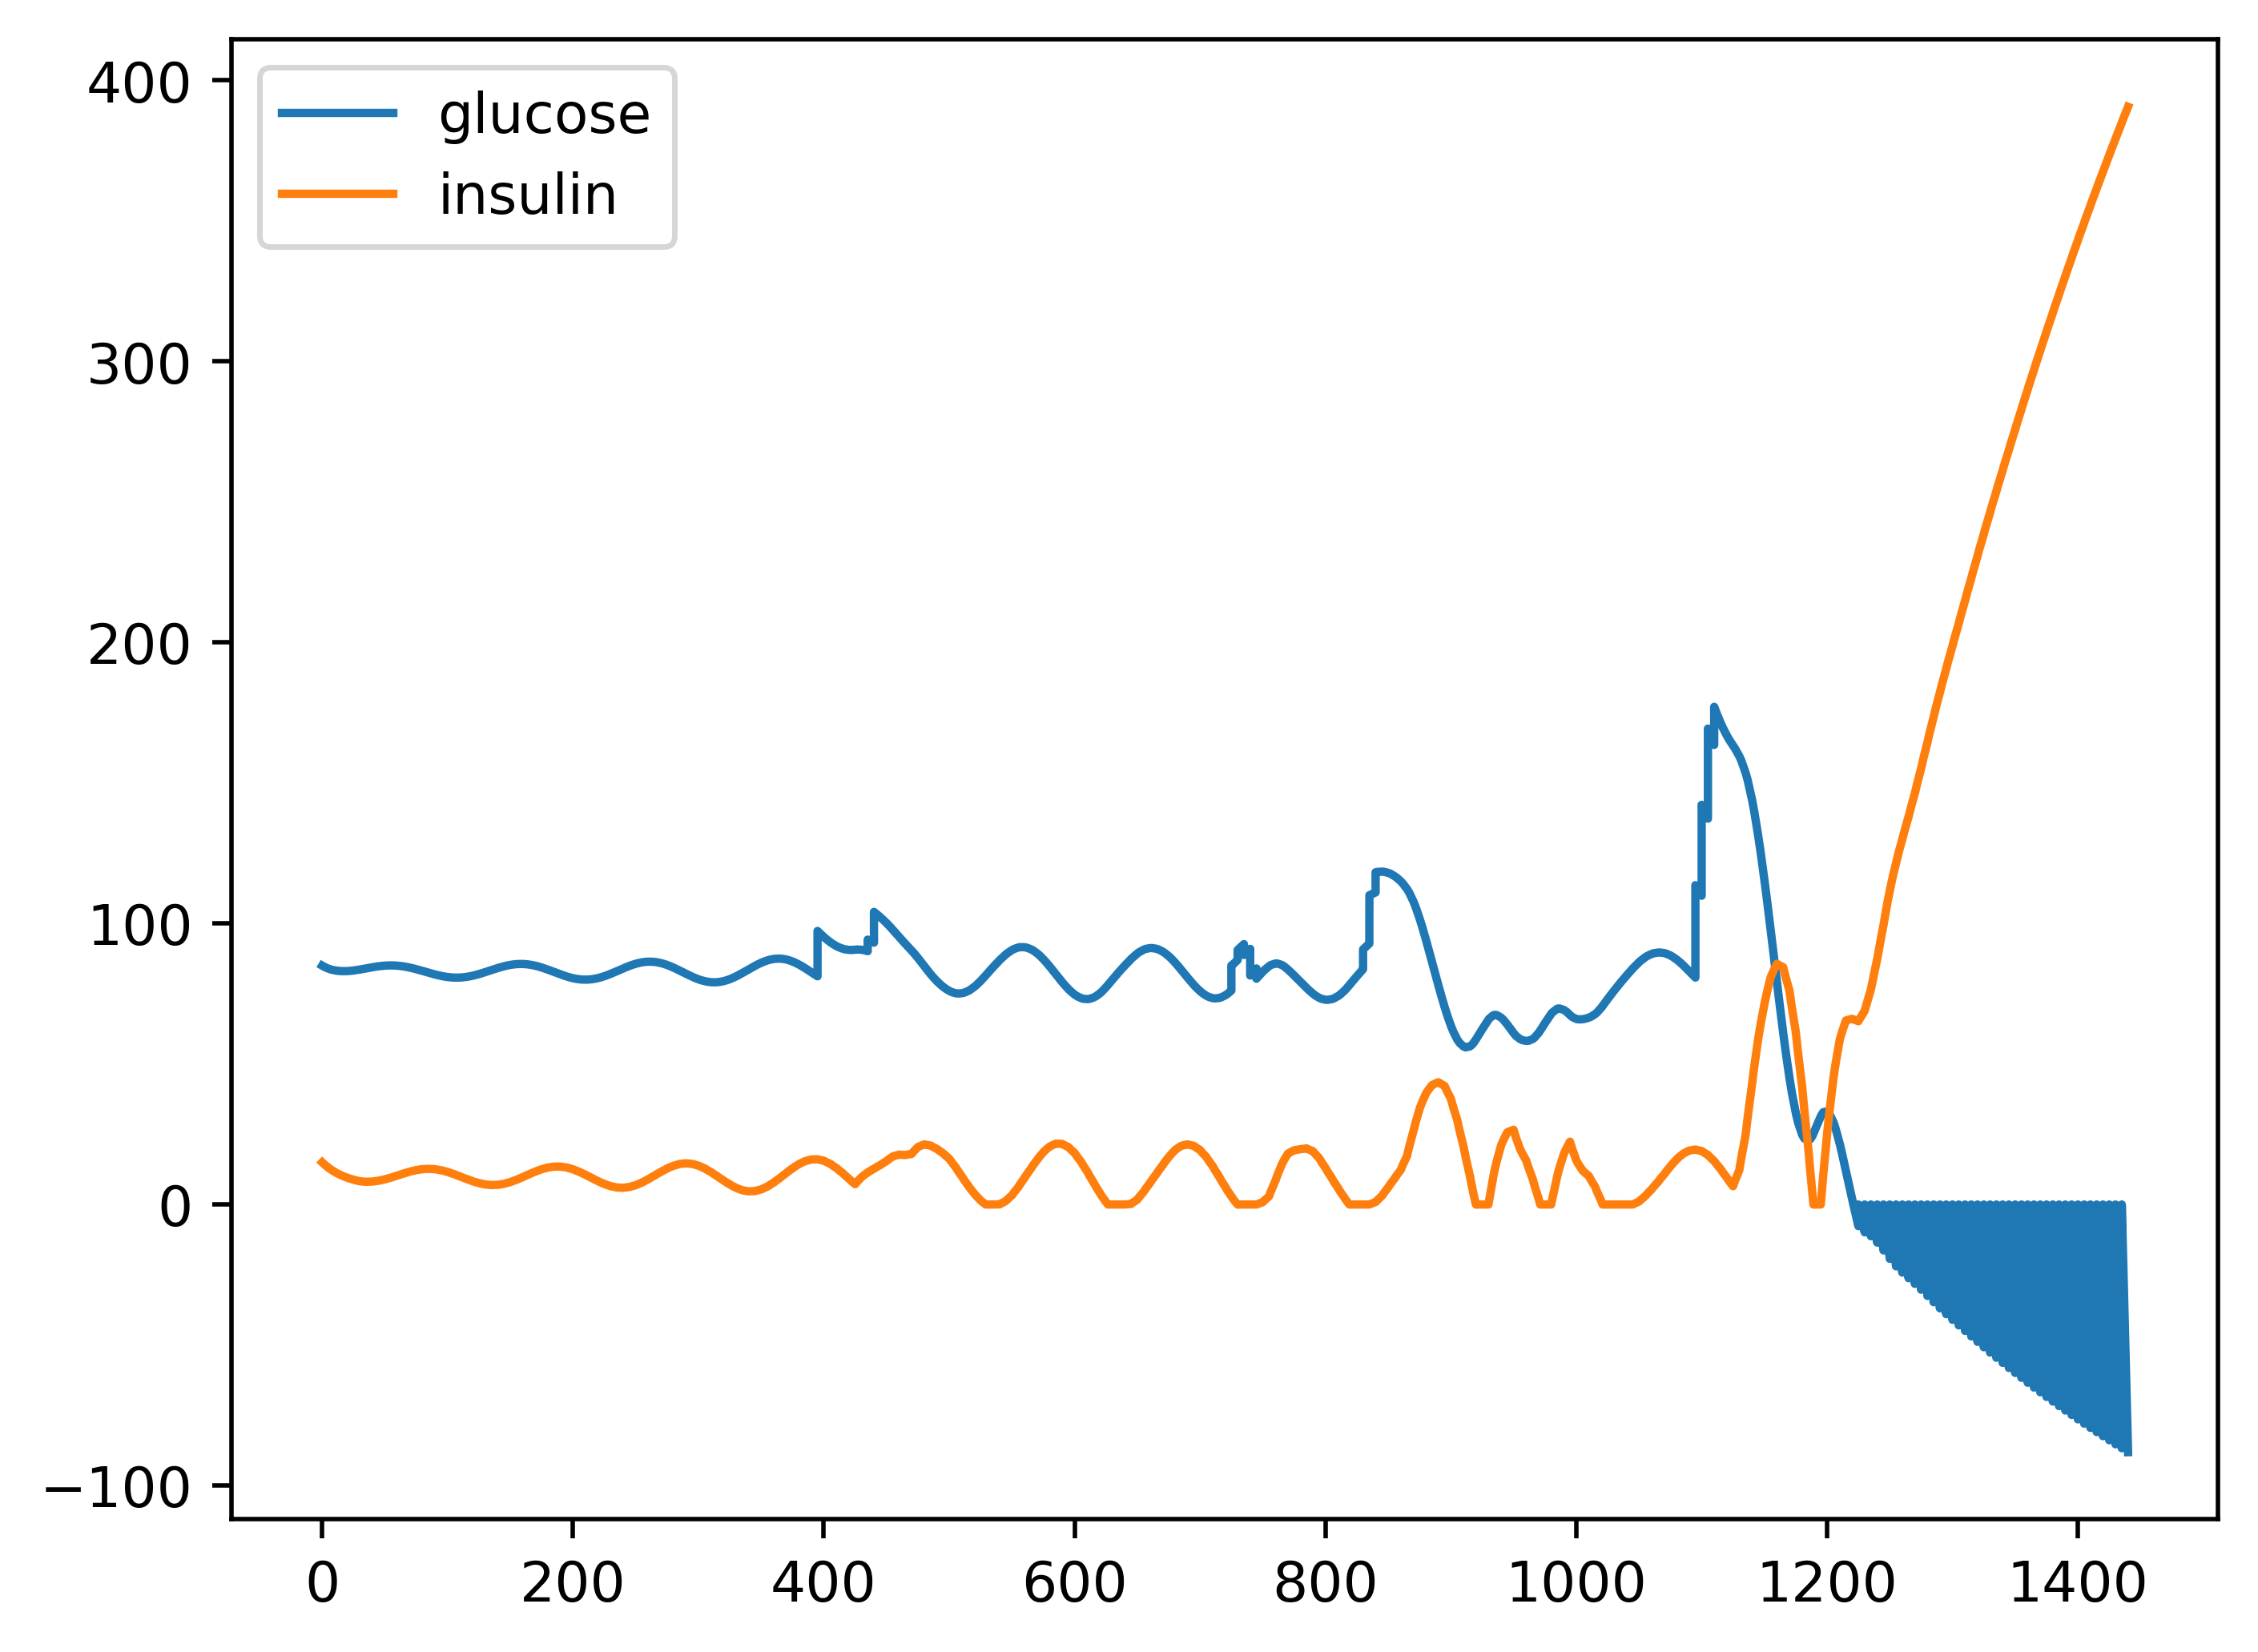

In [109]:
t_steps = 1440
dt = 5
starting = np.array([85, 15])
a = 0.01
b = 0.05
c = 0.05
d = 0.0
glucose_penalty = 10
insulin_penalty = 5
controller_penalty = 1000
derivitive_penalty = 2
step_delay = 6
t, states = simulate(spikes, t_steps, dt, starting, a, b, c, d, glucose_penalty, insulin_penalty, controller_penalty, derivitive_penalty, target=83, base_insulin=10, step_delay=step_delay)

plt.plot(t, states[0], label='glucose')
plt.plot(t, states[1], label='insulin')
plt.legend()
plt.show()

In [110]:
t, states, estimates = simulate_kalman(spikes, t_steps, dt, starting, a, b, c, d, glucose_penalty, insulin_penalty, controller_penalty, derivitive_penalty, target=83, base_insulin=10, step_delay=step_delay)

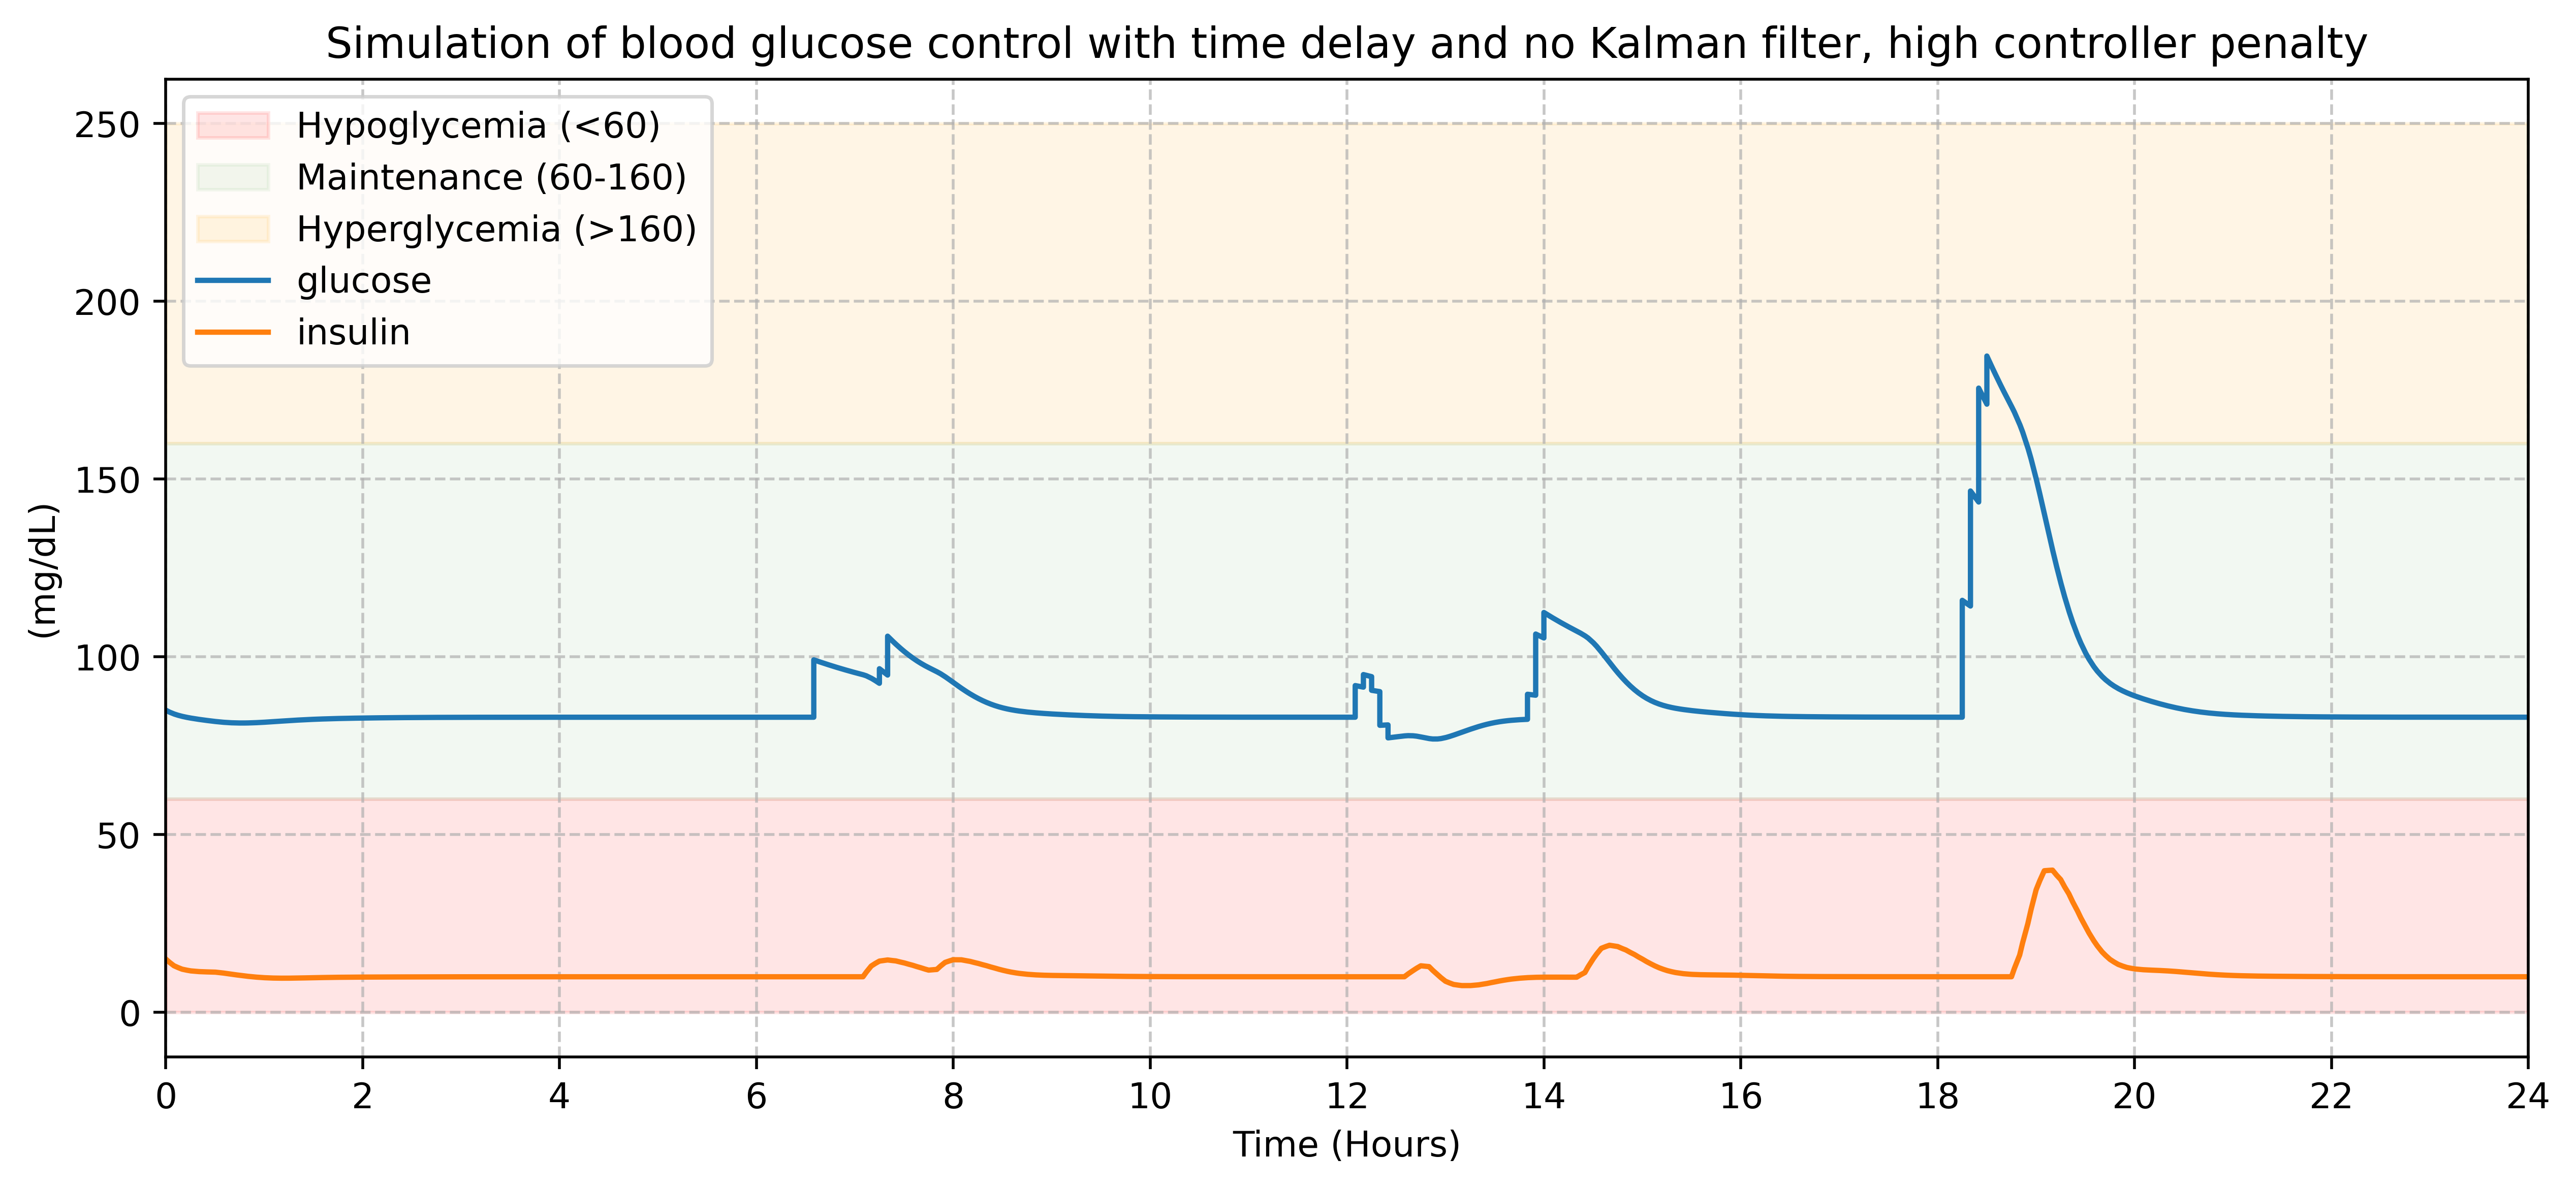

In [111]:
hours = t / 60.0

plt.figure(figsize=(12, 5))
plt.axhspan(0, 60, color='red', alpha=0.1, label='Hypoglycemia (<60)')
plt.axhspan(60, 160, color='green', alpha=0.05, label='Maintenance (60-160)')
plt.axhspan(160, 250, color='orange', alpha=0.1, label='Hyperglycemia (>160)')
plt.plot(hours, states[0], label='glucose')
plt.plot(hours, states[1], label='insulin')
# Formatting the plot
plt.title('Simulation of blood glucose control with time delay and no Kalman filter, high controller penalty')
plt.xlabel('Time (Hours)')
plt.ylabel('(mg/dL)')
plt.xlim(0, 24)
plt.xticks(np.arange(0, 25, 2)) # Set tick marks every 2 hours
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

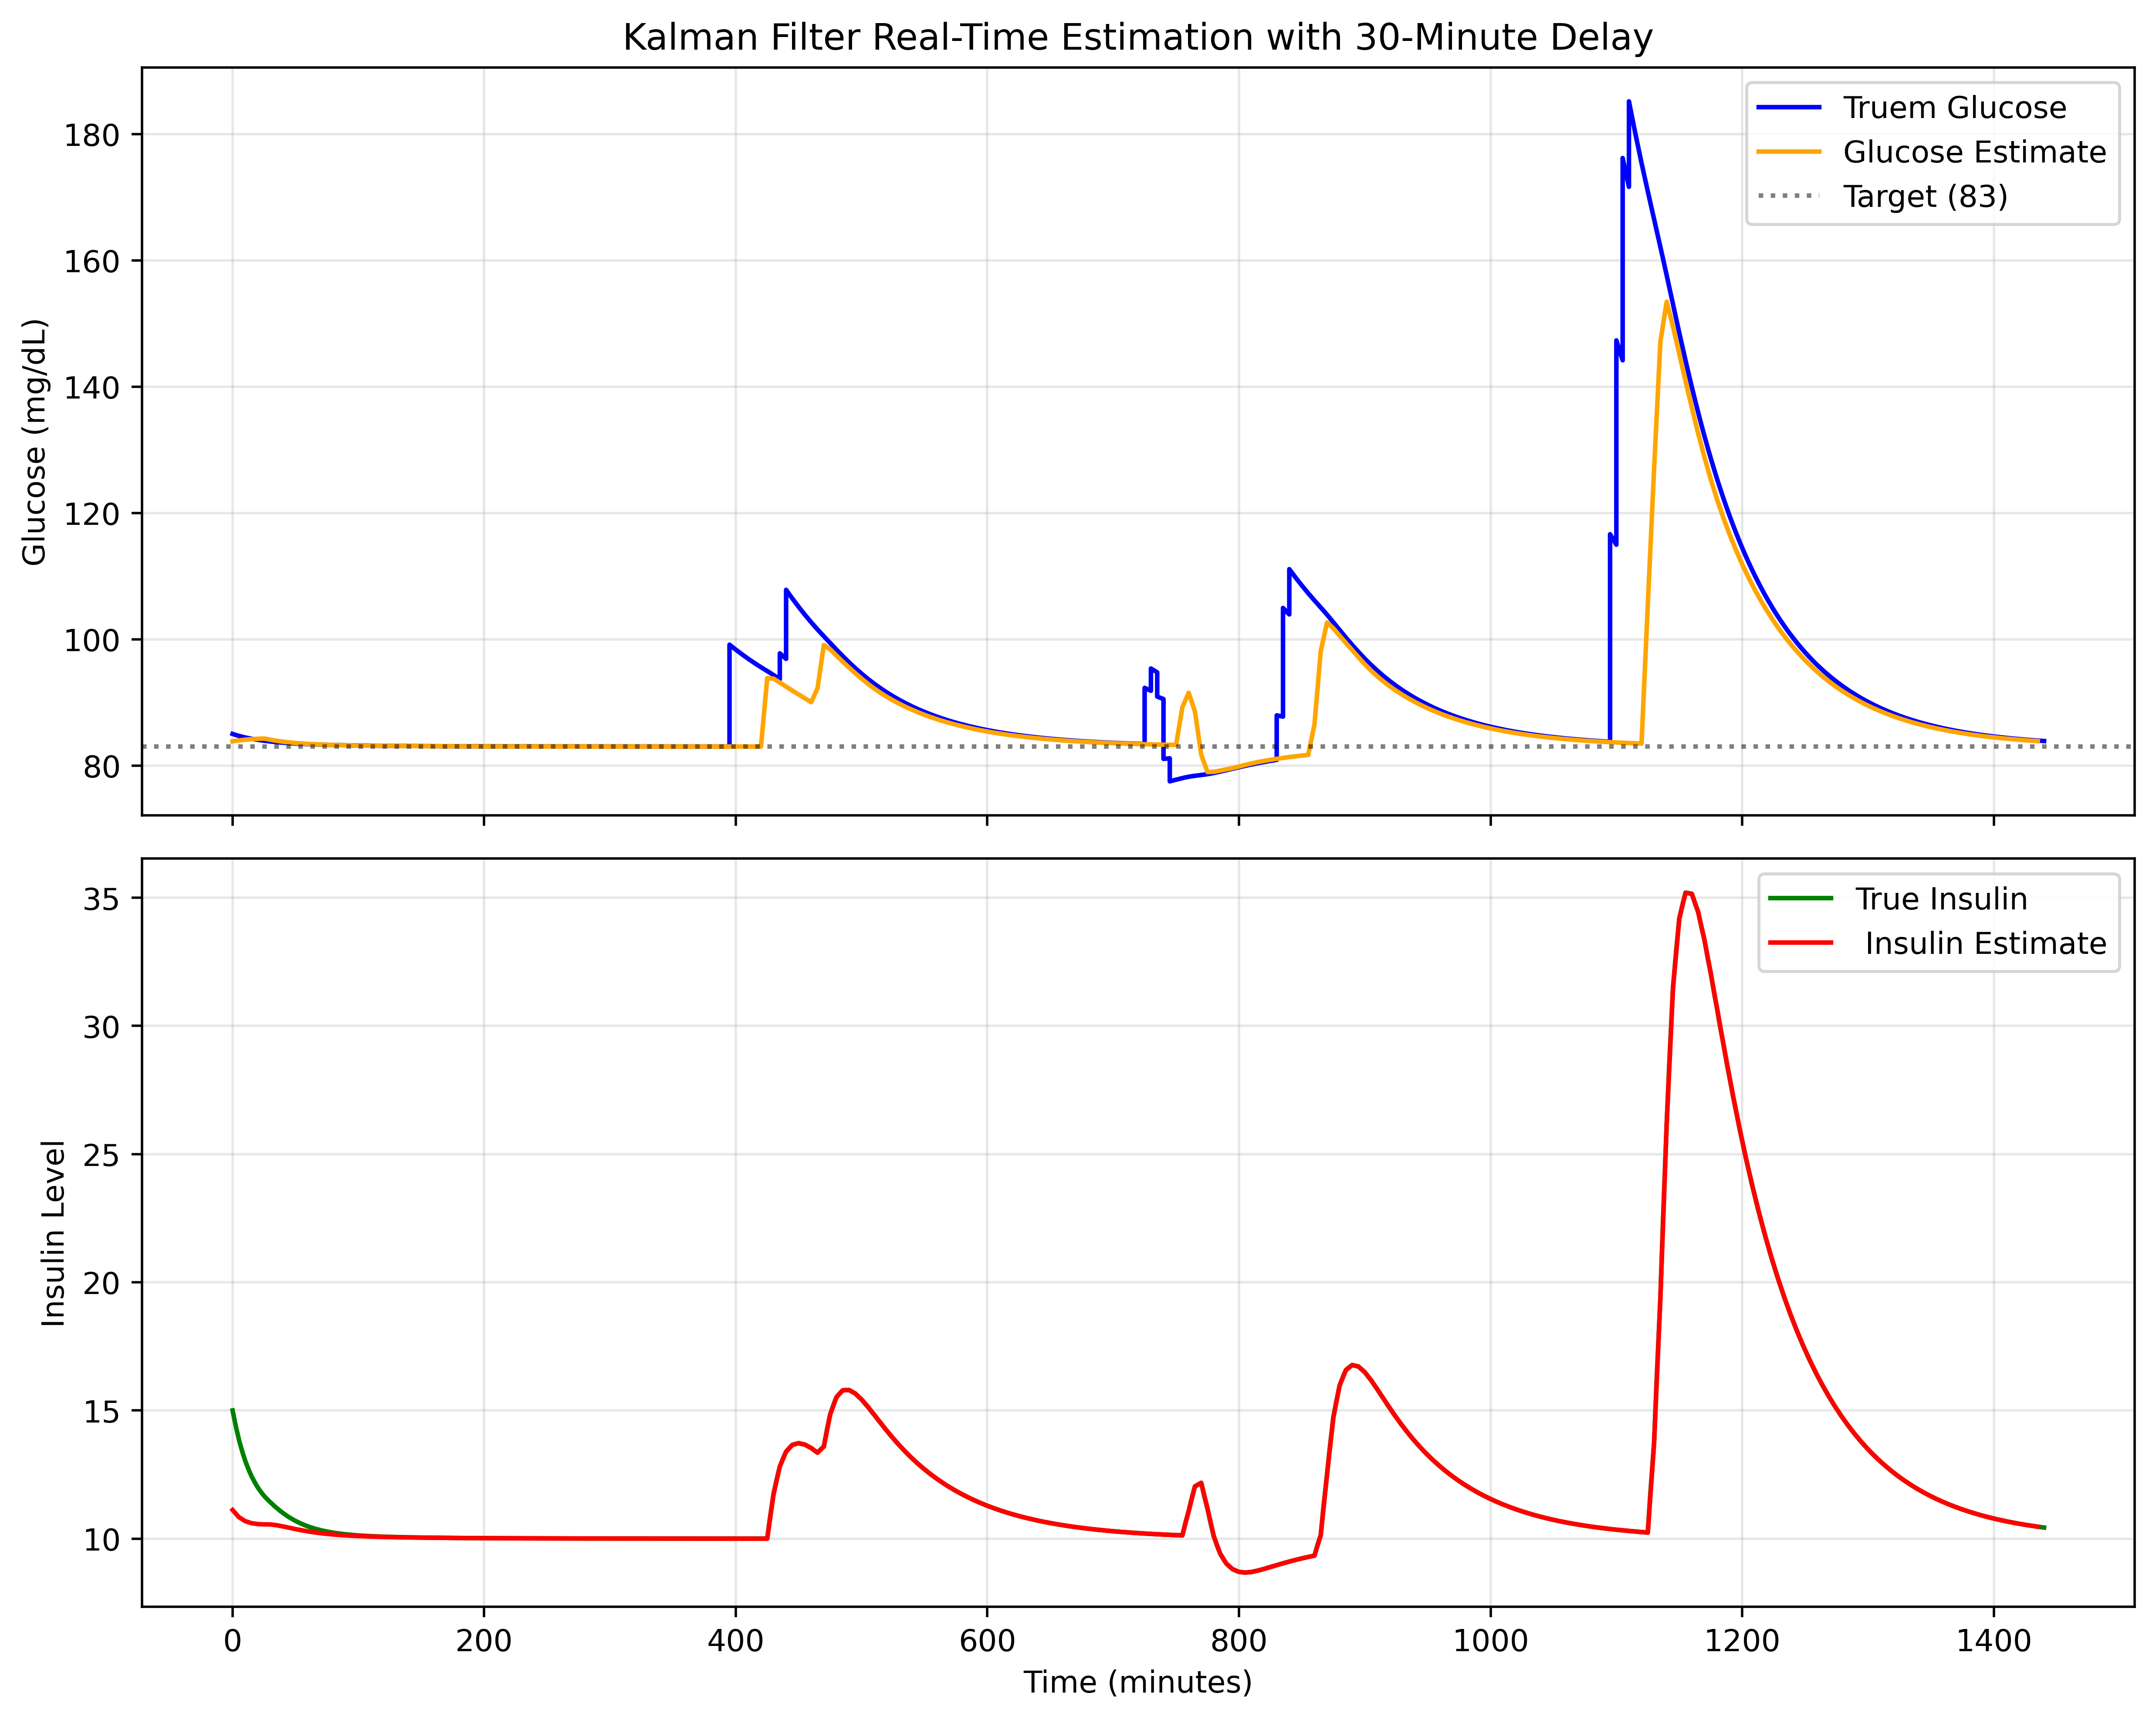

In [107]:

true_glucose = states[0, :]
true_insulin = states[1, :]
est_glucose = estimates[0, :]
est_insulin = estimates[1, :]
t_discrete = np.arange(0, t_steps, dt)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
ax1.plot(t, true_glucose, label="Truem Glucose", color="blue")
ax1.plot(t_discrete, est_glucose, label="Glucose Estimate", color="orange")
ax1.axhline(83, color='black', linestyle=':', alpha=0.5, label="Target (83)")
ax1.set_ylabel("Glucose (mg/dL)")
ax1.set_title("Kalman Filter Real-Time Estimation with 30-Minute Delay")
ax1.legend()
ax1.grid(alpha=0.3)
ax2.plot(t, true_insulin, label="True Insulin", color="green")
ax2.plot(t_discrete, est_insulin, label=" Insulin Estimate", color="red")
ax2.set_xlabel("Time (minutes)")
ax2.set_ylabel("Insulin Level")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()